# microgpt from first principles

This notebook builds a tiny educational GPT in pure Python, inspired by Andrej Karpathy's `microgpt`. The implementation is intentionally scalar-based: every weight is a Python number wrapped in a tiny autograd object instead of a tensor. That makes it extremely slow compared with real training code, but it also makes the learning algorithm visible.

We will build a minimal document completer, not a conversational assistant. Given the beginning of a short document, the model learns to predict the next character, one step at a time, and can then continue a sequence autoregressively.

The main design tradeoff is **algorithmic clarity versus computational efficiency**:

- clarity: we can see every forward pass, loss term, gradient, and optimizer update
- efficiency: we give up batching, GPUs, tensor kernels, and production-scale speed

**Roadmap**

`data -> tokenizer -> autograd -> parameters -> Transformer -> loss -> backpropagation -> Adam -> generation`

**References**

- Andrej Karpathy, *microgpt* article and implementation
- Dataflowr histogram notebook for toy Transformer-style tasks
- *Thinking Like Transformers* for RASP and mechanistic task design


In [1]:
import os
import math
import json
import random
import tempfile
import urllib.request
from dataclasses import dataclass
from pathlib import Path

FAST_MODE = True
SEED = 42
random.seed(SEED)

# Matplotlib writes a config cache on first import; point it at a writable temp dir
os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig_"))

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception as exc:
    MATPLOTLIB_AVAILABLE = False
    plt = None
    print(f"matplotlib unavailable: {exc}")

print("FAST_MODE =", FAST_MODE)
print("SEED =", SEED)
print("matplotlib available =", MATPLOTLIB_AVAILABLE)


Matplotlib is building the font cache; this may take a moment.


FAST_MODE = True
SEED = 42
matplotlib available = True


## Tiny offline datasets

The notebook uses three built-in datasets so it runs without internet access:

1. a tiny names dataset
2. a repeating symbolic-pattern dataset
3. a tiny structured phrase dataset

Each experiment will reuse the same model implementation and training utilities.


In [2]:
NAMES_DOCS = [
    "emma", "olivia", "ava", "mia", "liam", "noah", "luca", "nora",
    "ella", "mila", "lena", "ezra", "iris", "theo", "ruby", "jude",
    "clio", "arlo", "sana", "enzo", "kaia", "mina", "nova", "remy",
]

PATTERN_DOCS = [
    "abababab",
    "abcabcabc",
    "aabbaabb",
    "abababca",
    "abcabca",
    "aabbaabba",
]

STRUCTURED_DOCS = [
    "red circle",
    "blue square",
    "green triangle",
    "red square",
    "blue circle",
    "green square",
    "red triangle",
    "blue triangle",
    "green circle",
]

print("names examples:", NAMES_DOCS[:5])
print("pattern examples:", PATTERN_DOCS[:3])
print("structured examples:", STRUCTURED_DOCS[:3])


names examples: ['emma', 'olivia', 'ava', 'mia', 'liam']
pattern examples: ['abababab', 'abcabcabc', 'aabbaabb']
structured examples: ['red circle', 'blue square', 'green triangle']


The next cell is optional. It tries to download a larger names list when internet access is available, but the rest of the notebook does not depend on it.


In [3]:
OPTIONAL_NAMES_URL = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"

def try_download_names(url=OPTIONAL_NAMES_URL, timeout=5):
    try:
        with urllib.request.urlopen(url, timeout=timeout) as response:
            text = response.read().decode("utf-8")
        names = [line.strip() for line in text.splitlines() if line.strip()]
        print(f"downloaded {len(names)} names")
        return names
    except Exception as exc:
        print(f"optional download skipped: {exc}")
        return None

_optional_names = try_download_names()


downloaded 32033 names


## Character tokenizer

We use a character-level tokenizer. The vocabulary contains every unique character in the dataset, plus one special token named `BOS`.

In this implementation, the same `BOS` token can mark both the beginning and the end of a document. A training document is wrapped as:

` [BOS] + character tokens + [BOS] `

This works because the model sees the token in different positional and contextual situations. At position 0 it means “start reading”, while after the last real character it becomes the target for “end of document”.


In [4]:
class CharTokenizer:
    def __init__(self, docs):
        chars = sorted(set("".join(docs)))
        self.BOS_TOKEN = "<BOS>"
        self.vocab = chars + [self.BOS_TOKEN]
        self.stoi = {ch: i for i, ch in enumerate(self.vocab)}
        self.itos = {i: ch for ch, i in self.stoi.items()}
        self.BOS = self.stoi[self.BOS_TOKEN]
        self.vocab_size = len(self.vocab)

    def encode(self, text):
        return [self.stoi[ch] for ch in text]

    def decode(self, token_ids):
        chars = []
        for idx in token_ids:
            token = self.itos[idx]
            if token != self.BOS_TOKEN:
                chars.append(token)
        return "".join(chars)

    def wrap_document(self, text):
        return [self.BOS] + self.encode(text) + [self.BOS]

tokenizer_demo = CharTokenizer(NAMES_DOCS)
sample_text = "emma"
sample_encoded = tokenizer_demo.encode(sample_text)

print("vocabulary:", tokenizer_demo.vocab)
print("vocabulary size:", tokenizer_demo.vocab_size)
print("encoded sample:", sample_encoded)
assert tokenizer_demo.decode(tokenizer_demo.encode(sample_text)) == sample_text
print("round-trip test passed")


vocabulary: ['a', 'b', 'c', 'd', 'e', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'r', 's', 't', 'u', 'v', 'y', 'z', '<BOS>']
vocabulary size: 21
encoded sample: [4, 10, 10, 0]
round-trip test passed


## Scalar autograd

The `Value` class stores:

- a scalar number
- a gradient
- references to parent nodes in the computation graph
- a `_backward` function describing how to propagate gradients to those parents

Notice that gradients accumulate with `+=`, not `=`. That is essential when one value influences the result through multiple graph paths.


In [5]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = float(data)
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, power):
        assert isinstance(power, (int, float))
        out = Value(self.data ** power, (self,), f"**{power}")
        def _backward():
            self.grad += (power * (self.data ** (power - 1))) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * (other ** -1)

    def __rtruediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return other * (self ** -1)

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def log(self):
        assert self.data > 0.0, "log expects a positive input"
        out = Value(math.log(self.data), (self,), "log")
        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(self.data if self.data > 0 else 0.0, (self,), "relu")
        def _backward():
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)

        build(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label="a")
b = Value(3.0, label="b")
loss = a * b + a
loss.backward()

print("loss:", loss)
print("a.grad:", a.grad)
print("b.grad:", b.grad)
assert abs(a.grad - 4.0) < 1e-12
assert abs(b.grad - 2.0) < 1e-12


loss: Value(data=8.0000, grad=1.0000)
a.grad: 4.0
b.grad: 2.0


In [6]:
def finite_difference_grad(fn, x, eps=1e-6):
    return (fn(x + eps) - fn(x - eps)) / (2 * eps)

x = Value(1.5)
y = (x * x + 3.0 * x).relu()
y.backward()

numeric = finite_difference_grad(lambda t: max(t * t + 3.0 * t, 0.0), 1.5)
print("autograd grad:", x.grad)
print("finite-difference grad:", numeric)
assert abs(x.grad - numeric) < 1e-4


autograd grad: 6.0
finite-difference grad: 5.999999999062311


## Neural-network helper functions

We now add a few reusable helpers:

- random matrix initialization
- matrix-vector multiplication
- a numerically stable softmax
- RMSNorm


In [7]:
def make_vector(size, rng, scale=0.02):
    return [Value(rng.gauss(0.0, scale)) for _ in range(size)]

def make_matrix(rows, cols, rng, scale=0.02):
    return [[Value(rng.gauss(0.0, scale)) for _ in range(cols)] for _ in range(rows)]

def linear(weight, x, bias=None):
    assert len(weight[0]) == len(x)
    out = []
    for row in weight:
        total = Value(0.0)
        for w, xi in zip(row, x):
            total = total + w * xi
        out.append(total)
    if bias is not None:
        out = [yi + bi for yi, bi in zip(out, bias)]
    return out

def stable_softmax(logits):
    max_logit = max(v.data for v in logits)
    shifted = [v - max_logit for v in logits]
    exps = [v.exp() for v in shifted]
    denom = Value(0.0)
    for e in exps:
        denom = denom + e
    return [e / denom for e in exps]

def rmsnorm(x, eps=1e-8):
    mean_square = Value(0.0)
    for xi in x:
        mean_square = mean_square + xi * xi
    mean_square = mean_square / len(x)
    scale = (mean_square + eps) ** -0.5
    return [xi * scale for xi in x]

rng = random.Random(SEED)
mat = make_matrix(3, 4, rng)
vec = [Value(float(i + 1)) for i in range(4)]
out = linear(mat, vec)
probs = stable_softmax([Value(1.0), Value(2.0), Value(3.0)])
normed = rmsnorm([Value(1.0), Value(2.0), Value(3.0), Value(4.0)])

assert len(out) == 3
assert abs(sum(p.data for p in probs) - 1.0) < 1e-6
rms = math.sqrt(sum(v.data * v.data for v in normed) / len(normed))
assert abs(rms - 1.0) < 1e-5
print("helper tests passed")


helper tests passed


## Model configuration and parameters

We will use a very small architecture:

- `n_embd = 16`
- `n_head = 4`
- `n_layer = 1`
- `block_size = 16`

The model parameters include:

- token embeddings
- positional embeddings
- per-layer query, key, value, and output projections
- per-layer MLP expansion and projection
- the final language-model head

Parameters are stored in regular Python lists and flattened for optimization.


In [8]:
@dataclass
class MicroGPTConfig:
    n_embd: int = 16
    n_head: int = 4
    n_layer: int = 1
    block_size: int = 16
    weight_std: float = 0.02

    @property
    def head_size(self):
        assert self.n_embd % self.n_head == 0
        return self.n_embd // self.n_head


class MicroGPTModel:
    def __init__(self, tokenizer, config, rng):
        self.tokenizer = tokenizer
        self.config = config
        self.rng = rng
        c = config
        v = tokenizer.vocab_size

        self.token_embedding = make_matrix(v, c.n_embd, rng, c.weight_std)
        self.position_embedding = make_matrix(c.block_size, c.n_embd, rng, c.weight_std)
        self.layers = []
        for _ in range(c.n_layer):
            layer = {
                "wq": make_matrix(c.n_embd, c.n_embd, rng, c.weight_std),
                "wk": make_matrix(c.n_embd, c.n_embd, rng, c.weight_std),
                "wv": make_matrix(c.n_embd, c.n_embd, rng, c.weight_std),
                "wo": make_matrix(c.n_embd, c.n_embd, rng, c.weight_std),
                "w1": make_matrix(4 * c.n_embd, c.n_embd, rng, c.weight_std),
                "w2": make_matrix(c.n_embd, 4 * c.n_embd, rng, c.weight_std),
            }
            self.layers.append(layer)
        self.lm_head = make_matrix(v, c.n_embd, rng, c.weight_std)
        self.params = []
        self._collect_params()

    def _collect_params(self):
        params = []

        def visit(obj):
            if isinstance(obj, Value):
                params.append(obj)
            elif isinstance(obj, list):
                for item in obj:
                    visit(item)
            elif isinstance(obj, dict):
                for item in obj.values():
                    visit(item)

        visit(self.token_embedding)
        visit(self.position_embedding)
        visit(self.layers)
        visit(self.lm_head)
        self.params = params

    def parameter_count(self):
        return len(self.params)

    def zero_grad(self):
        for p in self.params:
            p.grad = 0.0

    def new_cache(self):
        caches = []
        for _ in range(self.config.n_layer):
            layer_cache = []
            for _ in range(self.config.n_head):
                layer_cache.append({"k": [], "v": []})
            caches.append(layer_cache)
        return caches

    def _embed(self, token_id, pos_id):
        tok = self.token_embedding[token_id]
        pos = self.position_embedding[pos_id]
        return [ti + pi for ti, pi in zip(tok, pos)]

    def forward_token(self, token_id, pos_id, cache, return_debug=False):
        c = self.config
        x = self._embed(token_id, pos_id)
        debug = {"heads": []} if return_debug else None

        for layer_idx, layer in enumerate(self.layers):
            residual = x
            xn = rmsnorm(x)
            q = linear(layer["wq"], xn)
            k = linear(layer["wk"], xn)
            v = linear(layer["wv"], xn)
            head_outputs = []
            head_debug = []

            for head_idx in range(c.n_head):
                start = head_idx * c.head_size
                end = (head_idx + 1) * c.head_size
                qh = q[start:end]
                kh = k[start:end]
                vh = v[start:end]

                head_cache = cache[layer_idx][head_idx]
                head_cache["k"].append(kh)
                head_cache["v"].append(vh)

                scores = []
                for past_k in head_cache["k"]:
                    score = Value(0.0)
                    for qa, ka in zip(qh, past_k):
                        score = score + qa * ka
                    score = score * (1.0 / math.sqrt(c.head_size))
                    scores.append(score)
                att = stable_softmax(scores)

                out_h = [Value(0.0) for _ in range(c.head_size)]
                for weight, past_v in zip(att, head_cache["v"]):
                    for i, vi in enumerate(past_v):
                        out_h[i] = out_h[i] + weight * vi
                head_outputs.extend(out_h)
                if return_debug:
                    head_debug.append([a.data for a in att])

            att_proj = linear(layer["wo"], head_outputs)
            x = [ri + ai for ri, ai in zip(residual, att_proj)]

            residual = x
            xn = rmsnorm(x)
            mlp_hidden = [h.relu() for h in linear(layer["w1"], xn)]
            mlp_out = linear(layer["w2"], mlp_hidden)
            x = [ri + mi for ri, mi in zip(residual, mlp_out)]

            if return_debug:
                debug["heads"].append(head_debug)

        logits = linear(self.lm_head, rmsnorm(x))
        if return_debug:
            return logits, debug
        return logits

demo_tokenizer = CharTokenizer(NAMES_DOCS)
demo_model = MicroGPTModel(demo_tokenizer, MicroGPTConfig(), random.Random(SEED))
print("total scalar parameters:", demo_model.parameter_count())


total scalar parameters: 4000


## Next-token loss

For a document like `"emma"`, the wrapped token sequence is:

` [BOS] e m m a [BOS] `

The model is trained with **teacher forcing**. At each position, it receives the current token and predicts the next one. The loss at position `t` is:

`loss_t = -log p(correct_next_token | prefix)`

The document loss is the average of these per-position losses.


In [9]:
def document_loss(model, tokenizer, text, return_details=False):
    tokens = tokenizer.wrap_document(text)
    cache = model.new_cache()
    losses = []
    details = []

    for pos in range(len(tokens) - 1):
        token_id = tokens[pos]
        target_id = tokens[pos + 1]
        logits = model.forward_token(token_id, pos, cache)
        probs = stable_softmax(logits)
        prob = probs[target_id]
        loss_t = -prob.log()
        losses.append(loss_t)

        if return_details:
            details.append({
                "pos": pos,
                "input_token": tokenizer.itos[token_id],
                "target_token": tokenizer.itos[target_id],
                "target_probability": prob.data,
                "loss": loss_t.data,
            })

    total = Value(0.0)
    for lt in losses:
        total = total + lt
    mean_loss = total / len(losses)

    if return_details:
        return mean_loss, details
    return mean_loss

loss_value, loss_details = document_loss(demo_model, demo_tokenizer, "emma", return_details=True)
assert math.isfinite(loss_value.data)
print("document loss:", loss_value.data)
print("first few positions:")
for row in loss_details[:4]:
    print(row)


document loss: 3.0342650906886024
first few positions:
{'pos': 0, 'input_token': '<BOS>', 'target_token': 'e', 'target_probability': 0.04647832530225519, 'loss': 3.0687691975898503}
{'pos': 1, 'input_token': 'e', 'target_token': 'm', 'target_probability': 0.05129273240987814, 'loss': 2.9702062052647604}
{'pos': 2, 'input_token': 'm', 'target_token': 'm', 'target_probability': 0.049540430417760246, 'loss': 3.004966166671217}
{'pos': 3, 'input_token': 'm', 'target_token': 'a', 'target_probability': 0.04331321745801307, 'loss': 3.1392974374820373}


## Manual Adam optimizer

We implement Adam directly:

- first moment buffer `m`
- second moment buffer `v`
- bias correction
- optional learning-rate decay
- gradient reset after each update


In [10]:
class Adam:
    def __init__(self, params, lr=0.05, betas=(0.9, 0.999), eps=1e-8, lr_decay=1.0):
        self.params = params
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.lr_decay = lr_decay
        self.t = 0
        self.m = [0.0 for _ in params]
        self.v = [0.0 for _ in params]

    def step(self):
        self.t += 1
        lr_t = self.lr * (self.lr_decay ** (self.t - 1))
        for i, p in enumerate(self.params):
            g = p.grad
            self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (g * g)
            m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)
            p.data -= lr_t * m_hat / (math.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for p in self.params:
            p.grad = 0.0

tiny_model = MicroGPTModel(demo_tokenizer, MicroGPTConfig(), random.Random(SEED))
optimizer = Adam(tiny_model.params, lr=0.01)
before = tiny_model.params[0].data
test_loss = document_loss(tiny_model, demo_tokenizer, "emma")
test_loss.backward()
optimizer.step()
optimizer.zero_grad()
after = tiny_model.params[0].data
assert before != after
print("parameter update test passed")


parameter update test passed


## Reusable training and generation utilities

To keep the notebook tidy, we wrap the common steps in helper functions.


In [11]:
def prepare_dataset(docs, seed, block_size):
    tokenizer = CharTokenizer(docs)
    shuffled = list(docs)
    rng = random.Random(seed)
    rng.shuffle(shuffled)
    return {
        "docs": shuffled,
        "tokenizer": tokenizer,
        "max_doc_len": max(len(doc) for doc in docs),
        "block_size": max(block_size, max(len(doc) for doc in docs) + 2),
    }

def choose_training_text(docs, rng):
    return docs[rng.randrange(len(docs))]

def train_microgpt(model, docs, tokenizer, steps, seed, print_every=25, lr=0.05, lr_decay=0.997):
    rng = random.Random(seed)
    optimizer = Adam(model.params, lr=lr, lr_decay=lr_decay)
    history = []

    for step in range(1, steps + 1):
        text = choose_training_text(docs, rng)
        loss = document_loss(model, tokenizer, text)
        assert math.isfinite(loss.data), "loss must stay finite"
        history.append(loss.data)
        model.zero_grad()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step == 1 or step % print_every == 0 or step == steps:
            print(f"step {step:4d} | train_loss {loss.data:.4f} | sample '{text}'")

    return {
        "history": history,
        "initial_loss": history[0],
        "final_loss": history[-1],
        "relative_improvement": (history[0] - history[-1]) / max(history[0], 1e-8),
    }

def sample_from_probs(probs, rng):
    threshold = rng.random()
    cumulative = 0.0
    for idx, p in enumerate(probs):
        cumulative += p.data
        if cumulative >= threshold:
            return idx
    return len(probs) - 1

def generate_one(model, tokenizer, rng, temperature=1.0, max_new_tokens=20, greedy=False):
    cache = model.new_cache()
    current = tokenizer.BOS
    produced = []
    limit = min(max_new_tokens, model.config.block_size)

    for pos in range(limit):
        logits = model.forward_token(current, pos, cache)
        if temperature <= 0:
            raise ValueError("temperature must be positive")
        scaled = [logit / temperature for logit in logits]
        probs = stable_softmax(scaled)
        next_token = max(range(len(probs)), key=lambda i: probs[i].data) if greedy else sample_from_probs(probs, rng)
        if next_token == tokenizer.BOS:
            break
        produced.append(next_token)
        current = next_token

    text = tokenizer.decode(produced)
    assert isinstance(text, str)
    return text

def generate_samples(model, tokenizer, temperatures, num_samples, max_new_tokens, seed, greedy=False):
    results = {}
    for i, temp in enumerate(temperatures):
        rng = random.Random(seed + 1000 * (i + 1))
        results[temp] = [
            generate_one(model, tokenizer, rng, temperature=temp, max_new_tokens=max_new_tokens, greedy=greedy)
            for _ in range(num_samples)
        ]
    return results

def show_loss_curve(history, title):
    if not MATPLOTLIB_AVAILABLE:
        print("matplotlib unavailable; skipping loss plot")
        return
    plt.figure(figsize=(6, 3))
    plt.plot(history, lw=2)
    plt.title(title)
    plt.xlabel("training step")
    plt.ylabel("loss")
    plt.grid(alpha=0.3)
    plt.show()


In [12]:
def inspect_attention(model, tokenizer, text, layer=0, head=0):
    wrapped = tokenizer.wrap_document(text)
    cache = model.new_cache()
    rows = []
    labels = []

    for pos, token_id in enumerate(wrapped[:-1]):
        logits, debug = model.forward_token(token_id, pos, cache, return_debug=True)
        _ = logits
        att_row = debug["heads"][layer][head]
        rows.append(att_row)
        labels.append(tokenizer.itos[token_id])

    size = len(rows)
    matrix = []
    for row in rows:
        padded = row + [0.0] * (size - len(row))
        matrix.append(padded)

    return labels, matrix

def run_experiment(name, docs, config, steps, temperatures, num_samples, seed_offset=0, max_new_tokens=20):
    print("=" * 80)
    print(name)
    print("=" * 80)
    prepared = prepare_dataset(docs, seed=SEED + seed_offset, block_size=config.block_size)
    tokenizer = prepared["tokenizer"]
    model = MicroGPTModel(tokenizer, config, random.Random(SEED + seed_offset))

    print("training examples:", prepared["docs"][:5])
    print("vocab size:", tokenizer.vocab_size)
    print("parameter count:", model.parameter_count())

    sample_doc = prepared["docs"][0]
    sample_loss, details = document_loss(model, tokenizer, sample_doc, return_details=True)
    print("manual inspection example:", sample_doc)
    for row in details[:min(5, len(details))]:
        print(row)
    print("initial single-document loss:", sample_loss.data)

    train_info = train_microgpt(
        model,
        prepared["docs"],
        tokenizer,
        steps=steps,
        seed=SEED + 17 + seed_offset,
        print_every=25 if FAST_MODE else 50,
        lr=0.05,
        lr_decay=0.998 if FAST_MODE else 0.999,
    )

    show_loss_curve(train_info["history"], f"{name} loss")
    print("initial loss:", round(train_info["initial_loss"], 4))
    print("final loss:", round(train_info["final_loss"], 4))
    print("relative improvement:", round(train_info["relative_improvement"] * 100, 2), "%")

    samples = generate_samples(
        model,
        tokenizer,
        temperatures=temperatures,
        num_samples=num_samples,
        max_new_tokens=max_new_tokens,
        seed=SEED + 999 + seed_offset,
        greedy=False,
    )
    for temp, outputs in samples.items():
        print(f"temperature={temp}")
        for text in outputs:
            print("  ", repr(text))

    return {
        "model": model,
        "tokenizer": tokenizer,
        "train_info": train_info,
        "samples": samples,
    }


## Experiment 1: names

This dataset is small enough that the model will often memorize local spelling patterns and invent plausible-looking new names.
Lower temperatures usually stay close to the training set; higher temperatures become more diverse and more error-prone.


Names experiment
training examples: ['jude', 'noah', 'sana', 'remy', 'theo']
vocab size: 21
parameter count: 4000
manual inspection example: jude
{'pos': 0, 'input_token': '<BOS>', 'target_token': 'j', 'target_probability': 0.05336990015963663, 'loss': 2.930508359358726}
{'pos': 1, 'input_token': 'j', 'target_token': 'u', 'target_probability': 0.04363520994543625, 'loss': 3.1318908869785003}
{'pos': 2, 'input_token': 'u', 'target_token': 'd', 'target_probability': 0.0475504770855199, 'loss': 3.0459634566968044}
{'pos': 3, 'input_token': 'd', 'target_token': 'e', 'target_probability': 0.054737125299570075, 'loss': 2.9052130922843973}
{'pos': 4, 'input_token': 'e', 'target_token': '<BOS>', 'target_probability': 0.04439803830493873, 'loss': 3.114559992841225}
initial single-document loss: 3.0256271576319307
step    1 | train_loss 3.0395 | sample 'ezra'
step   25 | train_loss 3.2380 | sample 'remy'
step   50 | train_loss 2.0366 | sample 'enzo'
step   75 | train_loss 1.7012 | sample 'mila'


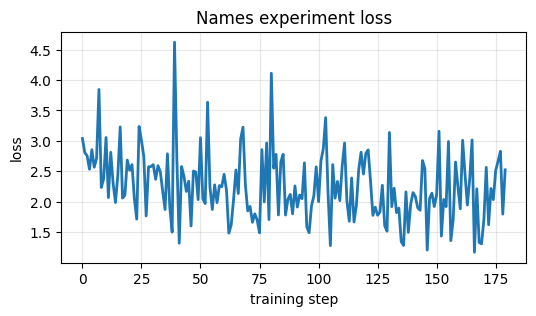

initial loss: 3.0395
final loss: 2.5257
relative improvement: 16.91 %
temperature=0.2
   'judu'
   'judj'
   'jujj'
   'uude'
temperature=0.7
   'eera'
   'uma'
   'jjdo'
   'kaia'
temperature=1.0
   'rnezua'
   'nuka'
   'mlill'
   'zjde'
novelty check:
temp=0.2 | 'judu'       | in training set = False
temp=0.2 | 'judj'       | in training set = False
temp=0.2 | 'jujj'       | in training set = False
temp=0.2 | 'uude'       | in training set = False
temp=0.7 | 'eera'       | in training set = False
temp=0.7 | 'uma'        | in training set = False
temp=0.7 | 'jjdo'       | in training set = False
temp=0.7 | 'kaia'       | in training set = True
temp=1.0 | 'rnezua'     | in training set = False
temp=1.0 | 'nuka'       | in training set = False
temp=1.0 | 'mlill'      | in training set = False
temp=1.0 | 'zjde'       | in training set = False


In [13]:
config = MicroGPTConfig(n_embd=16, n_head=4, n_layer=1, block_size=16)

names_steps = 180 if FAST_MODE else 1000
names_result = run_experiment(
    "Names experiment",
    NAMES_DOCS,
    config=config,
    steps=names_steps,
    temperatures=[0.2, 0.7, 1.0],
    num_samples=4,
    seed_offset=0,
    max_new_tokens=12,
)

train_set = set(NAMES_DOCS)
print("novelty check:")
for temp, outputs in names_result["samples"].items():
    for text in outputs:
        in_train = text in train_set
        print(f"temp={temp:>3} | {text!r:12} | in training set = {in_train}")


Plausible but invented names are a good reminder of what the model is doing: it is continuing character sequences that look likely under its training data. It is not reasoning about people, identity, or meaning.


## Experiment 2: repeated symbolic patterns

Here the model has to continue short symbolic regularities such as `ab`, `abc`, or `aabb`. Because the context window and dataset are tiny, failures are often informative: the model may drift, stop early, or mix patterns.


Pattern experiment
training examples: ['abababab', 'aabbaabb', 'aabbaabba', 'abcabcabc', 'abababca']
vocab size: 4
parameter count: 3456
manual inspection example: abababab
{'pos': 0, 'input_token': '<BOS>', 'target_token': 'a', 'target_probability': 0.2469529953917328, 'loss': 1.398557262521656}
{'pos': 1, 'input_token': 'a', 'target_token': 'b', 'target_probability': 0.24858387656743167, 'loss': 1.391974958937904}
{'pos': 2, 'input_token': 'b', 'target_token': 'a', 'target_probability': 0.25719248957788343, 'loss': 1.3579304877530955}
{'pos': 3, 'input_token': 'a', 'target_token': 'b', 'target_probability': 0.23834581896626106, 'loss': 1.4340326390573788}
{'pos': 4, 'input_token': 'b', 'target_token': 'a', 'target_probability': 0.27025531999698943, 'loss': 1.3083881371913049}
initial single-document loss: 1.3772729308522096
step    1 | train_loss 1.3913 | sample 'abcabcabc'
step   25 | train_loss 0.9630 | sample 'aabbaabba'
step   50 | train_loss 0.7411 | sample 'aabbaabba'
step   75

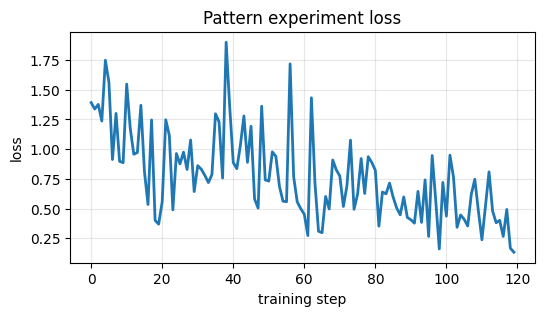

initial loss: 1.3913
final loss: 0.1323
relative improvement: 90.49 %
temperature=0.2
   'aabbaabb'
   'aabbaabb'
   'aabbaabb'
   'aabbaabb'
temperature=0.7
   'aabbaabb'
   'aabbaabb'
   'aabbaabb'
   'aabbaabb'
temperature=1.0
   'abcabcaa'
   'abcabcabca'
   'aabcaaaab'
   'aabbaabb'


In [14]:
pattern_steps = 120 if FAST_MODE else 600
pattern_result = run_experiment(
    "Pattern experiment",
    PATTERN_DOCS,
    config=config,
    steps=pattern_steps,
    temperatures=[0.2, 0.7, 1.0],
    num_samples=4,
    seed_offset=100,
    max_new_tokens=14,
)


The interesting question is not whether the model is perfect. It is whether we can see it learn the local transition structure well enough to generate convincing continuations most of the time.


## Experiment 3: structured phrases

This dataset follows a simple pattern:

`<color> <shape>`

If the model learns this format, many generations should preserve the general template even when it produces combinations that were not shown verbatim during training.


Structured phrase experiment
training examples: ['blue square', 'blue triangle', 'green triangle', 'red triangle', 'green circle']
vocab size: 16
parameter count: 3840
manual inspection example: blue square
{'pos': 0, 'input_token': '<BOS>', 'target_token': 'b', 'target_probability': 0.059956161160909204, 'loss': 2.814141631131057}
{'pos': 1, 'input_token': 'b', 'target_token': 'l', 'target_probability': 0.06113405186602404, 'loss': 2.7946862543633006}
{'pos': 2, 'input_token': 'l', 'target_token': 'u', 'target_probability': 0.06974234472928258, 'loss': 2.6629476172891575}
{'pos': 3, 'input_token': 'u', 'target_token': 'e', 'target_probability': 0.06264111539427401, 'loss': 2.770333421036123}
{'pos': 4, 'input_token': 'e', 'target_token': ' ', 'target_probability': 0.06136096482057299, 'loss': 2.790981398113037}
initial single-document loss: 2.7733651928896874
step    1 | train_loss 2.7734 | sample 'blue square'
step   25 | train_loss 1.0949 | sample 'blue triangle'
step   50 | train_l

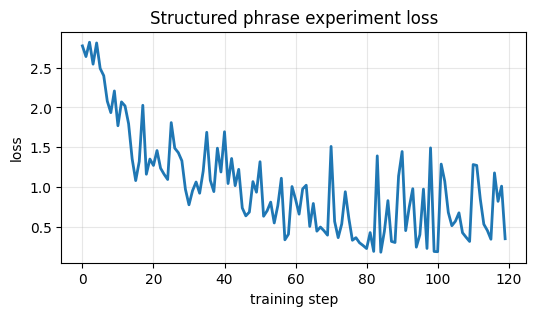

initial loss: 2.7734
final loss: 0.3507
relative improvement: 87.36 %
temperature=0.2
   'red  edrcre'
   'red  square'
   'red  edre'
   'green trare'
temperature=0.7
   'green tre'
   'green cianle'
   'blue crire'
   'green tranle'
temperature=1.0
   'bluib'
   'green trire'
   'lire trcbare'
   'red edbluile'
approximate structure check:
temp=0.2 | 'red  edrcre'        | follows <color> <shape> = False
temp=0.2 | 'red  square'        | follows <color> <shape> = True
temp=0.2 | 'red  edre'          | follows <color> <shape> = False
temp=0.2 | 'green trare'        | follows <color> <shape> = False
temp=0.7 | 'green tre'          | follows <color> <shape> = False
temp=0.7 | 'green cianle'       | follows <color> <shape> = False
temp=0.7 | 'blue crire'         | follows <color> <shape> = False
temp=0.7 | 'green tranle'       | follows <color> <shape> = False
temp=1.0 | 'bluib'              | follows <color> <shape> = False
temp=1.0 | 'green trire'        | follows <color> <shape> = Fal

In [15]:
phrase_steps = 120 if FAST_MODE else 600
phrase_result = run_experiment(
    "Structured phrase experiment",
    STRUCTURED_DOCS,
    config=config,
    steps=phrase_steps,
    temperatures=[0.2, 0.7, 1.0],
    num_samples=4,
    seed_offset=200,
    max_new_tokens=18,
)

colors = {"red", "blue", "green"}
shapes = {"circle", "square", "triangle"}
print("approximate structure check:")
for temp, outputs in phrase_result["samples"].items():
    for text in outputs:
        parts = text.split()
        follows_template = len(parts) == 2 and parts[0] in colors and parts[1] in shapes
        print(f"temp={temp:>3} | {text!r:20} | follows <color> <shape> = {follows_template}")


Even when the outputs follow the template, this is still sequence completion rather than symbolic understanding. The model has learned statistical regularities in character strings, not a formal ontology of colors and shapes.


## Compact attention inspection

Attention weights tell us which earlier positions a token looks at when building its representation. In a tiny model like this, the pictures can still be useful, but they should be interpreted cautiously:

- attention is not the whole model
- high attention does not automatically mean “the model understood this token”
- lightly trained toy models can show noisy or brittle patterns


attention labels: ['<BOS>', 'e', 'm', 'm', 'a']


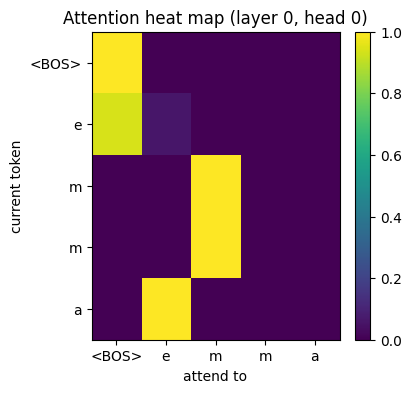

In [16]:
labels, matrix = inspect_attention(names_result["model"], names_result["tokenizer"], "emma", layer=0, head=0)
print("attention labels:", labels)

if MATPLOTLIB_AVAILABLE:
    plt.figure(figsize=(4, 4))
    plt.imshow(matrix, cmap="viridis", aspect="auto")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("attend to")
    plt.ylabel("current token")
    plt.title("Attention heat map (layer 0, head 0)")
    plt.colorbar()
    plt.show()
    plt.close()
else:
    print("attention matrix:")
    for row in matrix:
        print([round(x, 3) for x in row])


## Extension: histogram-style tasks and *Thinking Like Transformers*

The paper *Thinking Like Transformers* introduces **RASP**, a programming-language abstraction for describing computations that Transformer encoders can implement, including tasks like histogramming, sorting, and recognizing Dyck-language structure.

The referenced histogram notebook shows both hand-designed attention ideas and a trained GPT-like model for a toy counting problem. For example:

- input: `a a b a b c`
- target: `3 3 2 3 2 1`

That is **not** the same objective as our autoregressive next-character language model. To adapt microgpt to that task, we would need to change several things:

- data format: each input position needs an aligned target label
- output head: produce per-position class or count predictions, not just next-token logits
- forward API: run over the whole sequence and keep outputs at every position
- training objective: compare each position's output to its direct target instead of predicting the next character

So the histogram task is best viewed as a nearby conceptual extension, not something the current notebook solves without modification.


In [17]:
histogram_input = "a a b a b c".split()
histogram_target = [3, 3, 2, 3, 2, 1]
counts = {token: histogram_input.count(token) for token in sorted(set(histogram_input))}
reconstructed = [counts[token] for token in histogram_input]

print("histogram input: ", histogram_input)
print("target counts:   ", histogram_target)
print("count by symbol: ", counts)
print("reconstructed:   ", reconstructed)
assert reconstructed == histogram_target


histogram input:  ['a', 'a', 'b', 'a', 'b', 'c']
target counts:    [3, 3, 2, 3, 2, 1]
count by symbol:  {'a': 3, 'b': 2, 'c': 1}
reconstructed:    [3, 3, 2, 3, 2, 1]


## Limitations and production comparison

This notebook includes the essential GPT loop, but it is intentionally tiny and slow:

- scalar operations are far slower than tensor libraries
- there is no batching
- the tokenizer is character-level
- the model width, depth, and context length are tiny
- the datasets are tiny
- there is no checkpointing
- there is no GPU acceleration
- there is no mixed precision

Even so, the core ideas are all here: embeddings, attention, residual computation, next-token loss, backpropagation, Adam, and autoregressive generation.


## Exercises

1. Increase `n_embd`.
2. Add a second Transformer layer.
3. Change the dataset and compare the generations.
4. Compare greedy decoding with random sampling.
5. Plot attention at different training stages.
6. Add gradient clipping.
7. Add model checkpoint serialization.
8. Replace ReLU with another activation.
9. Implement a simple subword tokenizer.
10. Adapt the model or training objective to the histogram task.


## Export all figures and experiment results

This section collects the results from all three experiments into one folder. It saves:

- one loss-curve PNG for each experiment;
- the attention heat-map PNG;
- one detailed JSON file for each experiment;
- a compact `overview.json`; and
- a ZIP archive containing the complete export folder.

In VS Code or standard Jupyter, use the clickable ZIP link printed at the end of the cell. In Google Colab, set `AUTO_DOWNLOAD_IN_COLAB = True` to start the browser download automatically.


In [18]:
import shutil

ARTIFACT_DIR = Path.cwd() / "microgpt_outputs"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Colab can initiate a browser download. VS Code and standard Jupyter instead
# receive a clickable link because browsers generally block automatic downloads
# initiated by a local notebook kernel.
AUTO_DOWNLOAD_IN_COLAB = False


def save_loss_figure(history, title, path):
    """Save one experiment's training-loss curve."""
    if not MATPLOTLIB_AVAILABLE:
        return None

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(history, lw=2)
    ax.set_title(title)
    ax.set_xlabel("training step")
    ax.set_ylabel("loss")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return str(path.resolve())


def save_attention_figure(labels, matrix, path):
    """Save the inspected attention matrix as a heat map."""
    if not MATPLOTLIB_AVAILABLE:
        return None

    fig, ax = plt.subplots(figsize=(4, 4))
    image = ax.imshow(matrix, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("attend to")
    ax.set_ylabel("current token")
    ax.set_title("Attention heat map (layer 0, head 0)")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return str(path.resolve())


def summarize_experiment(result, docs, extra=None):
    """Convert an experiment result into JSON-serializable data."""
    summary = {
        "train_docs": list(docs),
        "vocab_size": result["tokenizer"].vocab_size,
        "parameter_count": result["model"].parameter_count(),
        "initial_loss": result["train_info"]["initial_loss"],
        "final_loss": result["train_info"]["final_loss"],
        "relative_improvement": result["train_info"]["relative_improvement"],
        "loss_history": result["train_info"]["history"],
        # JSON requires string keys; temperatures are therefore normalized here.
        "samples": {
            str(temperature): outputs
            for temperature, outputs in result["samples"].items()
        },
    }
    if extra is not None:
        summary["extra_checks"] = extra
    return summary


# Recreate the evaluation checks in a JSON-friendly format.
names_novelty = []
names_train_set = set(NAMES_DOCS)
for temperature, outputs in names_result["samples"].items():
    for text in outputs:
        names_novelty.append({
            "temperature": temperature,
            "text": text,
            "in_training_set": text in names_train_set,
        })

phrase_checks = []
valid_colors = {"red", "blue", "green"}
valid_shapes = {"circle", "square", "triangle"}
for temperature, outputs in phrase_result["samples"].items():
    for text in outputs:
        parts = text.split()
        phrase_checks.append({
            "temperature": temperature,
            "text": text,
            "follows_color_shape_template": (
                len(parts) == 2
                and parts[0] in valid_colors
                and parts[1] in valid_shapes
            ),
        })

experiment_summaries = {
    "names": summarize_experiment(
        names_result,
        NAMES_DOCS,
        extra={"novelty": names_novelty},
    ),
    "patterns": summarize_experiment(
        pattern_result,
        PATTERN_DOCS,
    ),
    "structured_phrases": summarize_experiment(
        phrase_result,
        STRUCTURED_DOCS,
        extra={"template_checks": phrase_checks},
    ),
}

# Save all figures.
figure_paths = {
    "names_loss": save_loss_figure(
        names_result["train_info"]["history"],
        "Names experiment loss",
        ARTIFACT_DIR / "names_loss.png",
    ),
    "patterns_loss": save_loss_figure(
        pattern_result["train_info"]["history"],
        "Pattern experiment loss",
        ARTIFACT_DIR / "patterns_loss.png",
    ),
    "structured_phrases_loss": save_loss_figure(
        phrase_result["train_info"]["history"],
        "Structured phrase experiment loss",
        ARTIFACT_DIR / "structured_phrases_loss.png",
    ),
    "attention_heatmap": save_attention_figure(
        labels,
        matrix,
        ARTIFACT_DIR / "attention_heatmap.png",
    ),
}

# Save one detailed JSON file per experiment.
for experiment_name, summary in experiment_summaries.items():
    json_path = ARTIFACT_DIR / f"{experiment_name}_summary.json"
    json_path.write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

# Save a compact index for quickly comparing experiments.
overview = {
    "seed": SEED,
    "fast_mode": FAST_MODE,
    "artifact_directory": str(ARTIFACT_DIR.resolve()),
    "config": {
        "n_embd": config.n_embd,
        "n_head": config.n_head,
        "n_layer": config.n_layer,
        "block_size": config.block_size,
    },
    "figures": figure_paths,
    "experiments": {
        experiment_name: {
            "initial_loss": summary["initial_loss"],
            "final_loss": summary["final_loss"],
            "relative_improvement": summary["relative_improvement"],
        }
        for experiment_name, summary in experiment_summaries.items()
    },
}
overview_path = ARTIFACT_DIR / "overview.json"
overview_path.write_text(
    json.dumps(overview, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

# Rebuild the ZIP each time so it always reflects the current run.
archive_base = ARTIFACT_DIR.parent / ARTIFACT_DIR.name
archive_path = Path(
    shutil.make_archive(
        str(archive_base),
        "zip",
        root_dir=ARTIFACT_DIR,
    )
)

print("Export directory:", ARTIFACT_DIR.resolve())
print("Exported files:")
for exported_path in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", exported_path.name)
print("ZIP archive:", archive_path.resolve())

# VS Code and standard Jupyter: display a clickable link to the ZIP.
try:
    from IPython.display import FileLink, display
    display(FileLink(str(archive_path), result_html_prefix="Download all results: "))
except Exception as exc:
    print(f"Clickable download link unavailable: {exc}")

# Google Colab: optionally initiate the browser download immediately.
try:
    from google.colab import files
    if AUTO_DOWNLOAD_IN_COLAB:
        files.download(str(archive_path))
    else:
        print("Colab detected. Set AUTO_DOWNLOAD_IN_COLAB = True and rerun this cell for automatic download.")
except ImportError:
    pass


Export directory: /Users/karinawijaya/Downloads/microgpt_outputs
Exported files:
 - attention_heatmap.png
 - names_loss.png
 - names_summary.json
 - overview.json
 - patterns_loss.png
 - patterns_summary.json
 - structured_phrases_loss.png
 - structured_phrases_summary.json
ZIP archive: /Users/karinawijaya/Downloads/microgpt_outputs.zip


/Users/karinawijaya/Downloads/microgpt_outputs.zip

In [19]:
# Final sanity checks that summarize the tutorial's guarantees.
assert tokenizer_demo.decode(tokenizer_demo.encode("ava")) == "ava"

test_logits = names_result["model"].forward_token(
    names_result["tokenizer"].BOS,
    0,
    names_result["model"].new_cache(),
)
assert len(test_logits) == names_result["tokenizer"].vocab_size
assert math.isfinite(names_result["train_info"]["final_loss"])

generated = generate_one(
    names_result["model"],
    names_result["tokenizer"],
    random.Random(SEED),
    temperature=0.7,
    max_new_tokens=12,
)
assert isinstance(generated, str)

expected_artifacts = {
    "overview.json",
    "names_summary.json",
    "patterns_summary.json",
    "structured_phrases_summary.json",
}
if MATPLOTLIB_AVAILABLE:
    expected_artifacts.update({
        "names_loss.png",
        "patterns_loss.png",
        "structured_phrases_loss.png",
        "attention_heatmap.png",
    })

assert ARTIFACT_DIR.exists()
assert expected_artifacts.issubset({
    path.name for path in ARTIFACT_DIR.iterdir()
})
assert archive_path.exists()

# Confirm that every generated JSON file can be parsed.
for json_path in ARTIFACT_DIR.glob("*.json"):
    with json_path.open("r", encoding="utf-8") as file:
        json.load(file)

print("All sequential notebook and export checks passed.")


All sequential notebook and export checks passed.
